In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

data = pd.read_csv("kolkata_iphone_sales.csv")
print(data)

             date store_id                  area                 store_type  \
0      2025-09-01   KOL001           Park Street  Apple Authorised Reseller   
1      2025-09-01   KOL001           Park Street  Apple Authorised Reseller   
2      2025-09-01   KOL003  Salt Lake (Sector V)           Reliance Digital   
3      2025-09-01   KOL003  Salt Lake (Sector V)           Reliance Digital   
4      2025-09-01   KOL003  Salt Lake (Sector V)           Reliance Digital   
...           ...      ...                   ...                        ...   
13427  2026-08-31   KOL018            Ballygunge  Apple Authorised Reseller   
13428  2026-08-31   KOL018            Ballygunge  Apple Authorised Reseller   
13429  2026-08-31   KOL018            Ballygunge  Apple Authorised Reseller   
13430  2026-08-31   KOL018            Ballygunge  Apple Authorised Reseller   
13431  2026-08-31   KOL019             Lake Town                Vijay Sales   

            iphone_model storage  color  units_sold

In [110]:
#Find Maximum Price Phone

max_price_phn = data.loc[data.unit_price_inr.idxmax()]

print("Model : ",max_price_phn["iphone_model"])
print("Max Price : " , max_price_phn["unit_price_inr"])

Model :  iPhone 16 Pro Max
Max Price :  223800


In [111]:
# Find Minimum Price Phone

min_price_phn = data.loc[data.unit_price_inr.idxmin()]

print("Model : ," , min_price_phn["iphone_model"])
print("Min Price : " , min_price_phn["unit_price_inr"])

Model : , iPhone 13
Min Price :  53910


In [112]:
# Calculate The Total Unit Sell Of Each Model

sold_unit = data.groupby("iphone_model")["units_sold"].sum()
sold_unit = sold_unit.sort_values(ascending=False)
sold_unit = sold_unit.reset_index()

print(sold_unit)

        iphone_model  units_sold
0      iPhone 16 Pro        2088
1  iPhone 16 Pro Max        2023
2          iPhone 14        1998
3          iPhone 15        1983
4          iPhone 16        1952
5     iPhone 15 Plus        1948
6     iPhone 16 Plus        1943
7          iPhone 13        1914


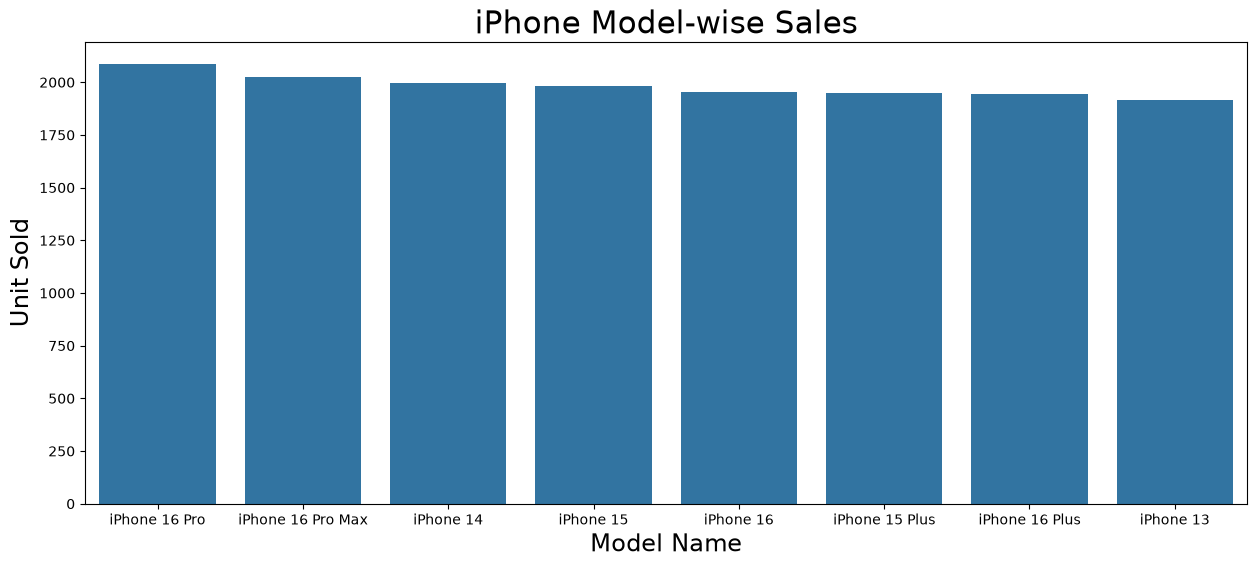

In [113]:
# Sold Unit vs Phone Model Graph

plt.figure(figsize = (15,6))
sb.barplot(data=sold_unit , x="iphone_model" , y="units_sold")
plt.title("iPhone Model-wise Sales" , fontsize=22)
plt.xlabel("Model Name" , fontsize=17)
plt.ylabel("Unit Sold" , fontsize=17)
plt.xticks(rotation=0)

plt.show()

In [114]:
# Color Wise Sales Analysis

color_model_sales = data.groupby(["color" , "iphone_model"]).size()
color_model_sales = color_model_sales.sort_values(ascending=False)
color_model_sales = color_model_sales.reset_index()
color_model_sales.columns = ["Color" , "Model" , "Total_Sales"]

print(color_model_sales)

               Color              Model  Total_Sales
0              Green          iPhone 14          324
1              Black      iPhone 16 Pro          322
2               Blue          iPhone 15          311
3               Blue     iPhone 15 Plus          308
4               Pink      iPhone 16 Pro          305
5              Green     iPhone 15 Plus          302
6              White      iPhone 16 Pro          298
7               Blue  iPhone 16 Pro Max          298
8              Black  iPhone 16 Pro Max          297
9              Green     iPhone 16 Plus          296
10  Natural Titanium          iPhone 14          296
11             White  iPhone 16 Pro Max          294
12             Black          iPhone 15          294
13  Natural Titanium          iPhone 13          292
14             Black     iPhone 15 Plus          292
15  Natural Titanium          iPhone 16          291
16             Green  iPhone 16 Pro Max          289
17  Natural Titanium      iPhone 16 Pro       

In [115]:
# Storage Wise Sales Analysis

storage_sales = data.groupby("storage")["units_sold"].sum()
storage_sales = storage_sales.sort_values(ascending=False)
storage_sales = storage_sales.reset_index()

storage_sales.columns = ["Storage", "Total_Sales"]

print(storage_sales)

  Storage  Total_Sales
0     1TB         4073
1   128GB         3967
2   256GB         3959
3   512GB         3850


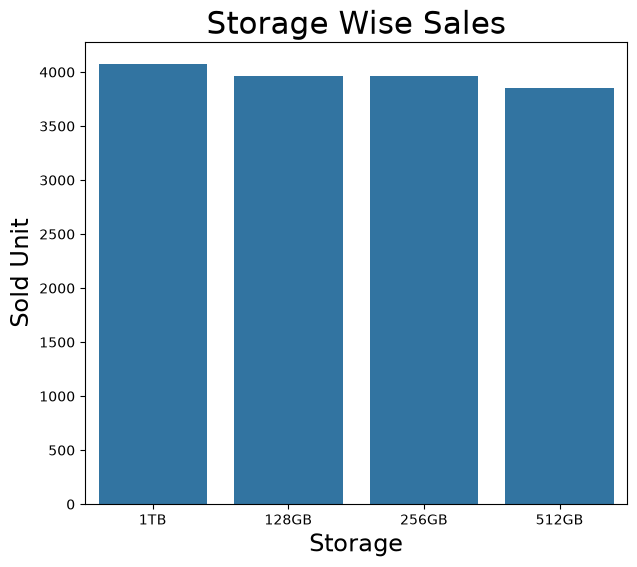

In [116]:
# Storage VS Sold Unit Graph

plt.figure(figsize=(7,6))
sb.barplot(data=storage_sales , x="Storage" , y="Total_Sales")
plt.title("Storage Wise Sales" , fontsize=22)
plt.xlabel("Storage" , fontsize=17)
plt.ylabel("Sold Unit" , fontsize=17)

plt.show()

In [117]:
# Analaysis Pyment Method

paymnt_Method = data.groupby("payment_mode")["units_sold"].sum()
paymnt_Method = paymnt_Method.reset_index()

print(paymnt_Method)

  payment_mode  units_sold
0         Cash         771
1  Credit Card        3943
2   Debit Card        2414
3          EMI        4032
4          UPI        4689


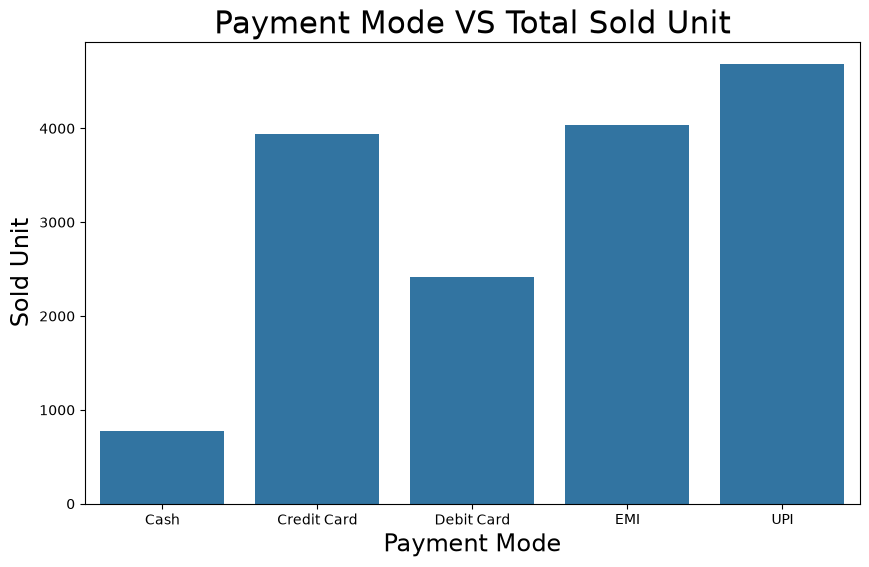

In [118]:
# Payment MMode VS Total Sold Unit

plt.figure(figsize=(10,6))
sb.barplot(data=paymnt_Method , x="payment_mode" , y="units_sold")
plt.title("Payment Mode VS Total Sold Unit" , fontsize=22)
plt.xlabel("Payment Mode" , fontsize=17)
plt.ylabel("Sold Unit" , fontsize=17)

plt.show()

In [119]:
# Area Wise Sales Analysis

area_sales = data.groupby("area")["units_sold"].sum()
area_sales = area_sales.reset_index()

print(area_sales)

                    area  units_sold
0             Ballygunge         810
1                 Behala        1776
2           Camac Street         775
3                Dum Dum         837
4              Esplanade         831
5               Gariahat         810
6                 Howrah         811
7              Lake Town         825
8             New Market        1563
9            Park Street        1710
10       Quest Mall Area         886
11            Rashbehari        1717
12  Salt Lake (Sector V)        1729
13       South City Mall         769


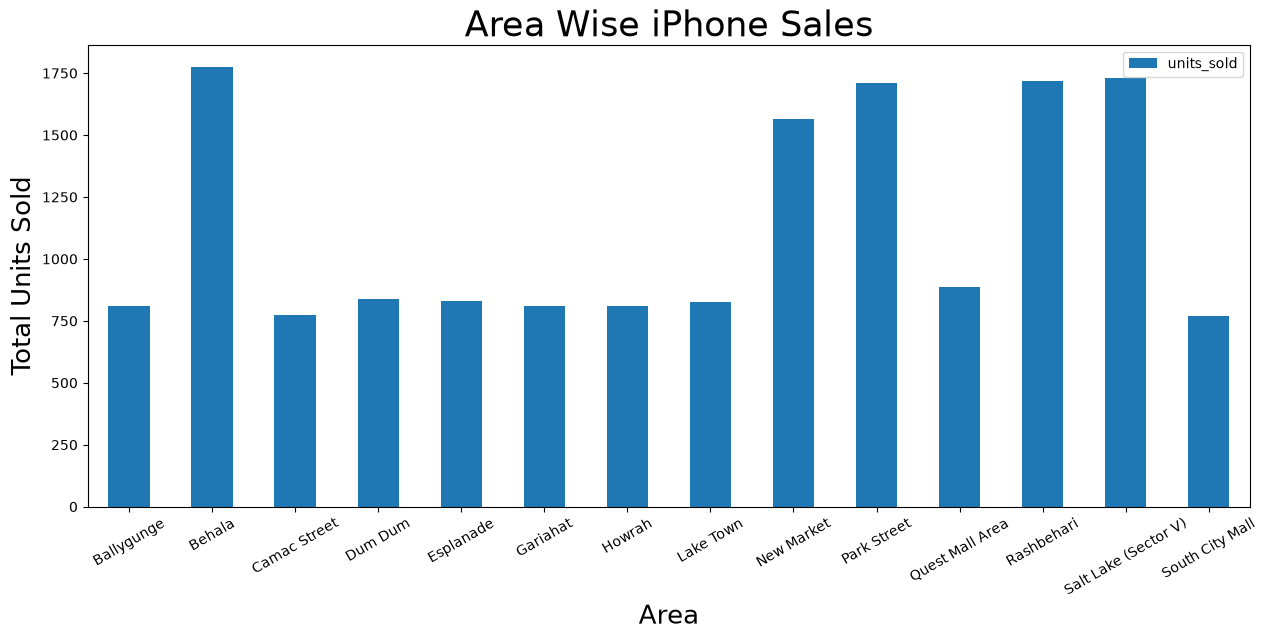

In [120]:
# Area Wise Sales Visualization

area_sales.plot(
    x="area", 
    y="units_sold", 
    kind="bar",
    figsize=(15,6)
)

plt.title("Area Wise iPhone Sales" , fontsize=25)
plt.xlabel("Area" , fontsize = 19)
plt.ylabel("Total Units Sold" , fontsize=19)
plt.xticks(rotation=30)

plt.show()